<a href="https://colab.research.google.com/github/bhuvankondapuram-glitch/assignment-01-STU2511083/blob/main/part4_vector_db_embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",

    # Cooking (3)
    "Cooking pasta requires boiling water",
    "Baking a cake needs precise measurements",
    "Frying vegetables enhances flavor",

    # Cybersecurity (4)
    "Cybersecurity protects systems from attacks",
    "Strong passwords prevent hacking",
    "Encryption secures communication",
    "Firewalls block unauthorized access"
]

In [12]:
!pip install sentence-transformers

In [13]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
embeddings = model.encode(sentences)

In [15]:
len(embeddings)

10

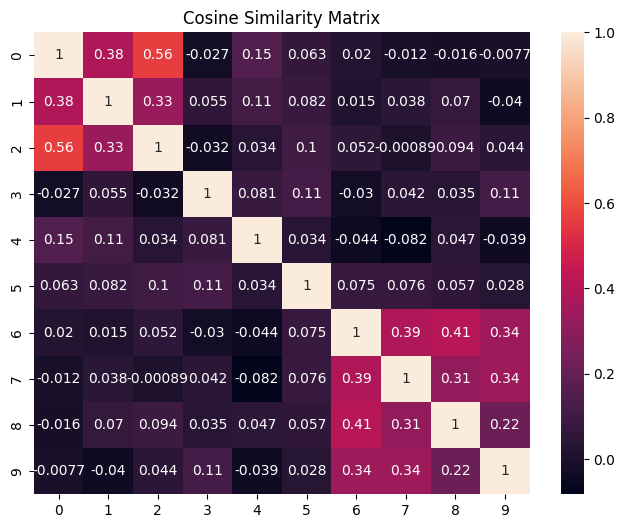

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True)
plt.title("Cosine Similarity Matrix")
plt.show()

In [17]:
query = "The bowler took three wickets in one over"

# Convert query to embedding
query_embedding = model.encode([query])

# Compute similarity with all sentences
from sklearn.metrics.pairwise import cosine_similarity
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
import numpy as np
top_indices = np.argsort(similarities)[-2:][::-1]

# Print results
for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Sentence: The batsman scored a century in the match
Similarity Score: 0.56821966

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5413827

